In [23]:
import seaborn as sns
import pandas as pd

In [24]:
df_facebook = pd.read_csv('facebook_ads_data (2.0).csv')

In [25]:
df_facebook.columns

Index(['ad_date', 'campaign_name', 'total_spend', 'total_impressions',
       'total_clicks', 'total_value', 'cpc', 'cpm', 'ctr', 'romi'],
      dtype='object')

In [26]:
df = df_facebook.groupby('ad_date')[['total_spend', 'total_impressions','total_clicks', 'total_value']].sum().reset_index()
df

,ad_date,total_spend,total_impressions,total_clicks,total_value
0,2020-11-11,1.89,1800,45,2.38
1,2020-11-12,23.00,10473,397,21.13
2,2020-11-13,6.36,11669,451,9.77
3,2020-11-14,7.27,5005,392,12.67
4,2020-11-15,6.98,12465,657,10.96
...,...,...,...,...,...
542,2022-10-29,714.03,33358,115,680.34
543,2022-10-30,335.91,27562,69,472.61
544,2022-10-31,227.45,6054,58,191.87
545,2022-11-01,0.00,0,0,0.00


In [27]:
df['ad_date'] = pd.to_datetime(df['ad_date'])  
df_2021 = df[df['ad_date'].dt.year == 2021] 

In [28]:
df_2021['romi'] = (df_2021['total_value'] / df_2021['total_spend']).round(2)
df_2021.head(15)

/tmp/ipykernel_249/2016364239.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_2021['romi'] = (df_2021['total_value'] / df_2021['total_spend']).round(2)


,ad_date,total_spend,total_impressions,total_clicks,total_value,romi
48,2021-01-01,0.39,353,0,0.59,1.51
49,2021-01-02,7.74,10709,205,6.90,0.89
50,2021-01-04,70.06,22440,1256,68.47,0.98
51,2021-01-05,81.15,60232,1379,61.68,0.76
52,2021-01-06,142.77,65265,431,145.97,1.02
53,2021-01-07,119.42,55885,1480,182.94,1.53
54,2021-01-08,61.97,33553,2641,85.03,1.37
55,2021-01-09,53.63,47079,708,40.94,0.76
56,2021-01-10,16.80,15045,679,15.86,0.94
57,2021-01-11,28.46,18584,650,32.44,1.14


In [29]:
df_2021['romi'].isna().sum()

2

In [30]:
df_2021 = df_2021.copy()  
df_2021['spend_rolling'] = df_2021['total_spend'].rolling(window=7).mean()
df_2021['romi_rolling'] = df_2021['romi'].rolling(window=7).mean()
df_2021 = df_2021.dropna().reset_index()
#df_2021 = df_2021.dropna()  
#df_2021.loc[:, 'spend_rolling'] = df_2021['total_spend'].rolling(window=7).mean().fillna(0)
#df_2021.loc[:, 'romi_rolling'] = df_2021['romi'].rolling(window=7).mean().fillna(0)
df_2021

,index,ad_date,total_spend,total_impressions,total_clicks,total_value,romi,spend_rolling,romi_rolling
0,54,2021-01-08,61.97,33553,2641,85.03,1.37,69.071429,1.151429
1,55,2021-01-09,53.63,47079,708,40.94,0.76,76.677143,1.044286
2,56,2021-01-10,16.80,15045,679,15.86,0.94,77.971429,1.051429
3,57,2021-01-11,28.46,18584,650,32.44,1.14,72.028571,1.074286
4,58,2021-01-12,136.70,39755,1658,219.81,1.61,79.964286,1.195714
...,...,...,...,...,...,...,...,...,...
310,372,2021-12-27,478.31,103725,504,686.47,1.44,367.521429,1.297143
311,373,2021-12-28,359.83,101788,499,450.47,1.25,343.310000,1.312857
312,374,2021-12-29,163.25,32290,435,171.76,1.05,336.875714,1.318571
313,375,2021-12-30,285.67,64171,984,330.26,1.16,319.571429,1.307143


In [31]:
import matplotlib.pyplot as plt
import pandas as pd

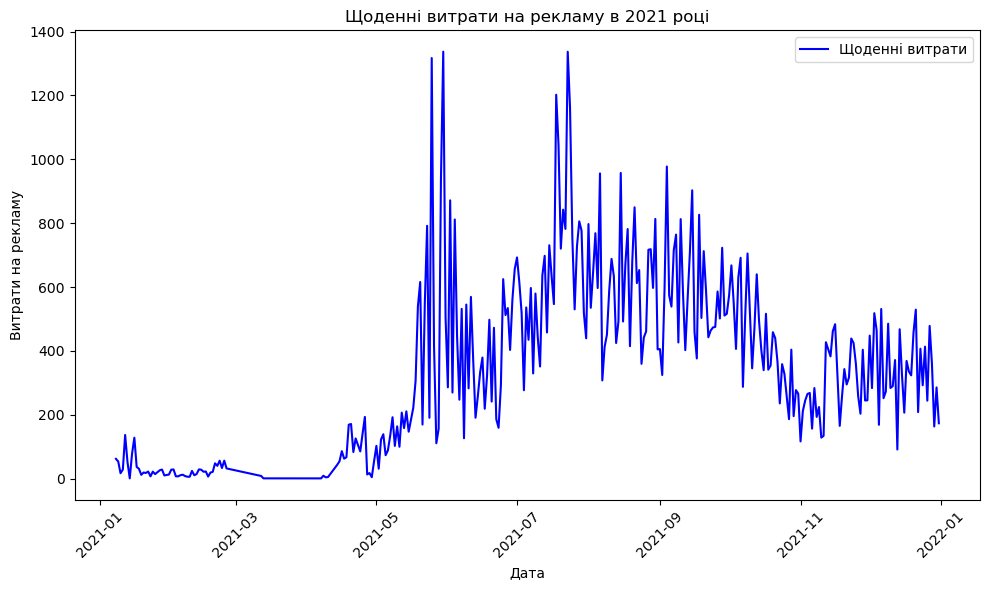

In [32]:
plt.figure(figsize=(10, 6))
plt.plot(df_2021['ad_date'], df_2021['total_spend'], color='blue', label='Щоденні витрати')
plt.xlabel('Дата')
plt.ylabel('Витрати на рекламу')
plt.title('Щоденні витрати на рекламу в 2021 році')
plt.xticks(rotation=45)
plt.legend()

plt.tight_layout()
plt.show()

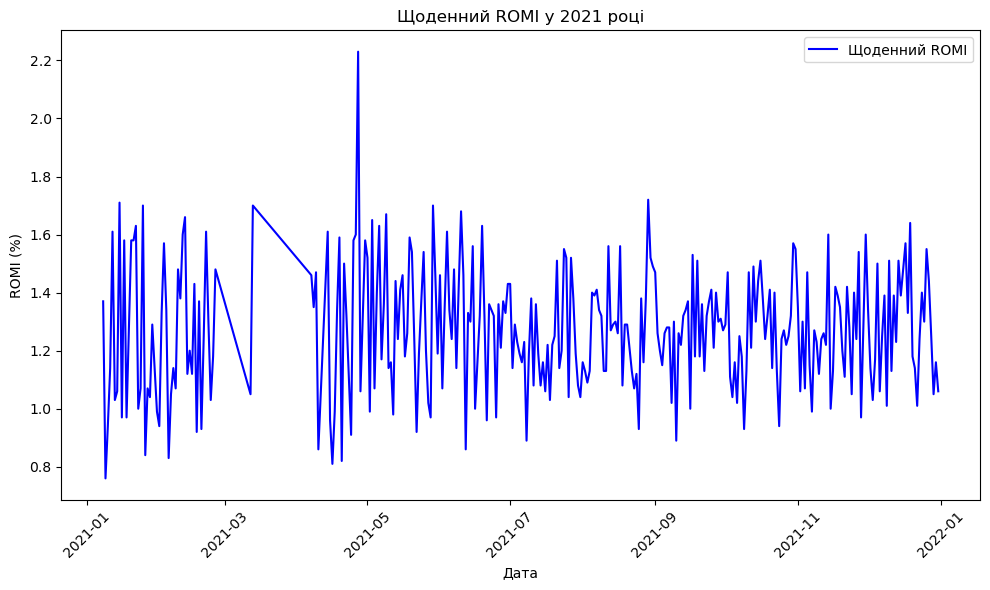

In [11]:
plt.figure(figsize=(10, 6))
plt.plot(df_2021['ad_date'], df_2021['romi'], color='blue', label='Щоденний ROMI')

plt.xlabel('Дата')
plt.ylabel('ROMI (%)')
plt.title('Щоденний ROMI у 2021 році')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

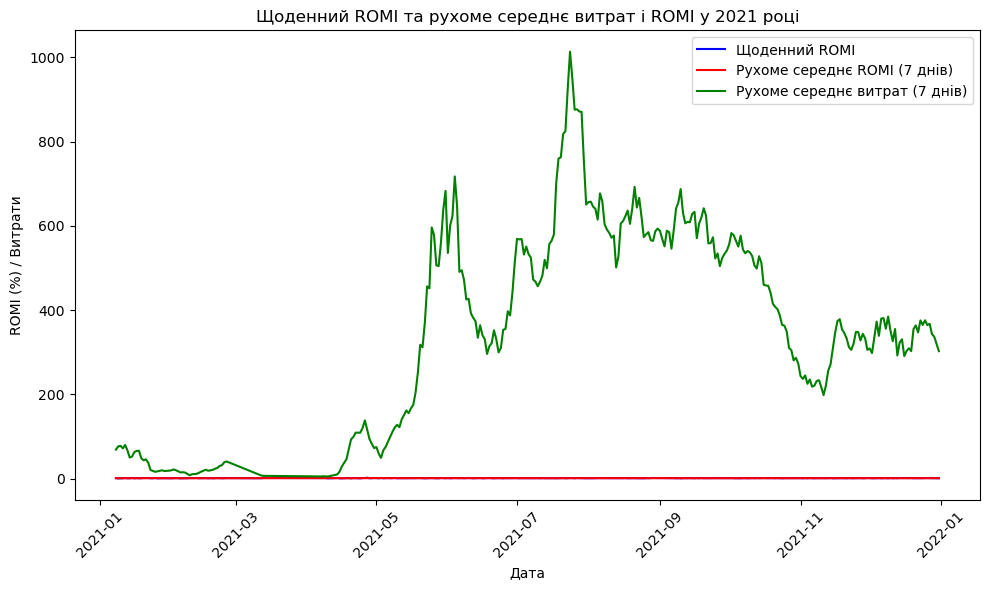

In [33]:
plt.figure(figsize=(10, 6))
plt.plot(df_2021['ad_date'], df_2021['romi'], color='blue', label='Щоденний ROMI')
plt.plot(df_2021['ad_date'], df_2021['romi_rolling'], color='red', label='Рухоме середнє ROMI (7 днів)')
plt.plot(df_2021['ad_date'], df_2021['spend_rolling'], color='green', label='Рухоме середнє витрат (7 днів)')
plt.xlabel('Дата')
plt.ylabel('ROMI (%) / Витрати')
plt.title('Щоденний ROMI та рухоме середнє витрат і ROMI у 2021 році')
plt.xticks(rotation=45)
plt.legend()
plt.tight_layout()
plt.show()

In [34]:
df_facebook.columns

Index(['ad_date', 'campaign_name', 'total_spend', 'total_impressions',
       'total_clicks', 'total_value', 'cpc', 'cpm', 'ctr', 'romi'],
      dtype='object')

In [35]:
df1 = df_facebook.groupby('campaign_name')[['total_spend', 'total_impressions','total_clicks', 'total_value']].sum().reset_index()


df1['romi'] = (df1['total_value'] / df1['total_spend']).round(2)
sorted_total_spend = df1.sort_values(by='total_spend', ascending=False)['campaign_name']
sorted_total_romi = df1.sort_values(by='romi', ascending=False)['campaign_name']
df1

,campaign_name,total_spend,total_impressions,total_clicks,total_value,romi
0,Brand,539.92,893854,542,670.15,1.24
1,Crazy discounts,2175.29,1401511,19627,2583.59,1.19
2,Discounts,2856.39,1256069,33353,3516.27,1.23
3,Electronics,23920.42,7070770,51593,29169.38,1.22
4,Expansion,67212.82,3736092,37469,83288.66,1.24
5,Hobbies,11326.97,8146187,50611,13974.63,1.23
6,Lookalike,63631.09,21019388,220993,80234.70,1.26
7,New items,2936.97,1045294,16935,3742.05,1.27
8,Promos,4993.84,2216422,17315,8793.77,1.76
9,Trendy,1992.31,1392189,9725,3798.90,1.91


In [36]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns


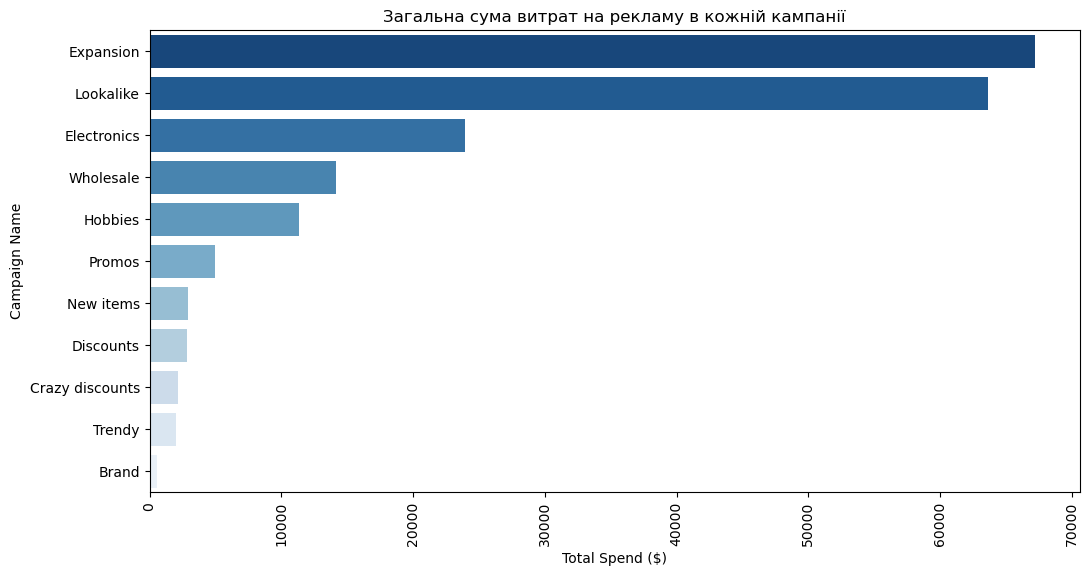

In [37]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df1, x='total_spend', y='campaign_name', palette="Blues_r", order=sorted_total_spend)
plt.xticks(rotation=90)
plt.title("Загальна сума витрат на рекламу в кожній кампанії")
plt.ylabel("Campaign Name")
plt.xlabel("Total Spend ($)")
plt.show()

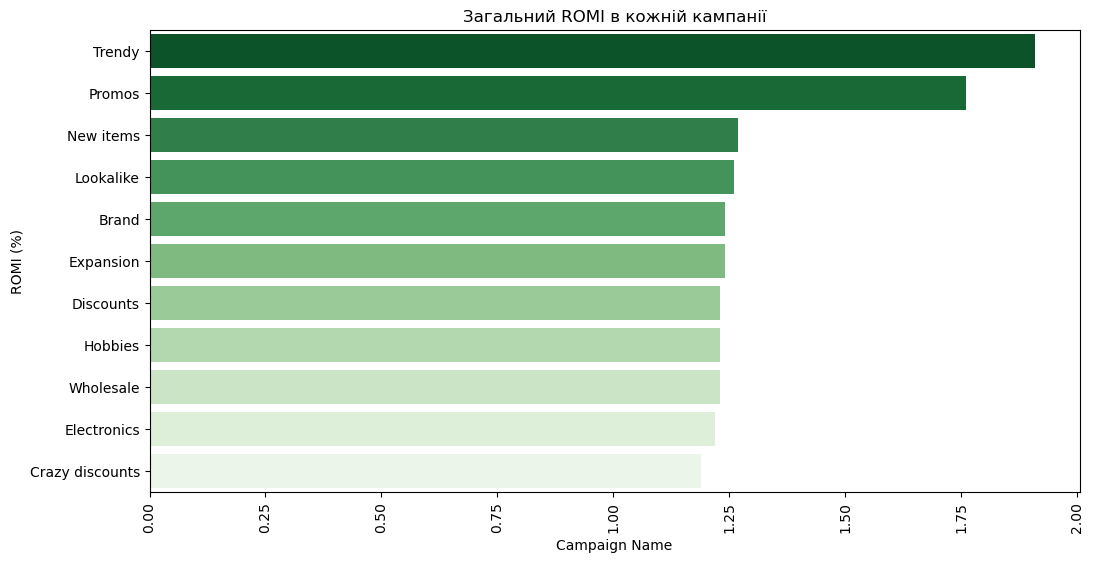

In [17]:
plt.figure(figsize=(12, 6))
sns.barplot(data=df1, x='romi', y='campaign_name', palette="Greens_r", order=sorted_total_romi)
plt.xticks(rotation=90)
plt.title("Загальний ROMI в кожній кампанії")
plt.ylabel("ROMI (%)")
plt.xlabel("Campaign Name")
plt.show()

In [39]:
df_4 = df_facebook.groupby(['ad_date','campaign_name'])[['total_spend', 'total_impressions','total_clicks', 'total_value']].sum().reset_index()
df_4 = df_4[df_4['total_spend'] > 0]
df_4['romi'] = (df['total_value'] / df['total_spend']).round(2)
df_4 = df_4.dropna().reset_index()
df_4

,index,ad_date,campaign_name,total_spend,total_impressions,total_clicks,total_value,romi
0,0,2020-11-11,Discounts,1.89,1800,45,2.38,1.26
1,1,2020-11-12,Discounts,23.00,10473,397,21.13,0.92
2,2,2020-11-13,Discounts,6.36,11669,451,9.77,1.54
3,3,2020-11-14,Discounts,7.27,5005,392,12.67,1.74
4,4,2020-11-15,Discounts,6.98,12465,657,10.96,1.57
...,...,...,...,...,...,...,...,...
529,540,2021-07-22,Wholesale,85.99,11233,262,117.97,1.05
530,541,2021-07-23,Crazy discounts,6.71,25988,294,10.87,0.94
531,542,2021-07-23,Electronics,312.46,106354,378,447.29,0.95
532,543,2021-07-23,Lookalike,735.74,218342,1594,804.00,1.41


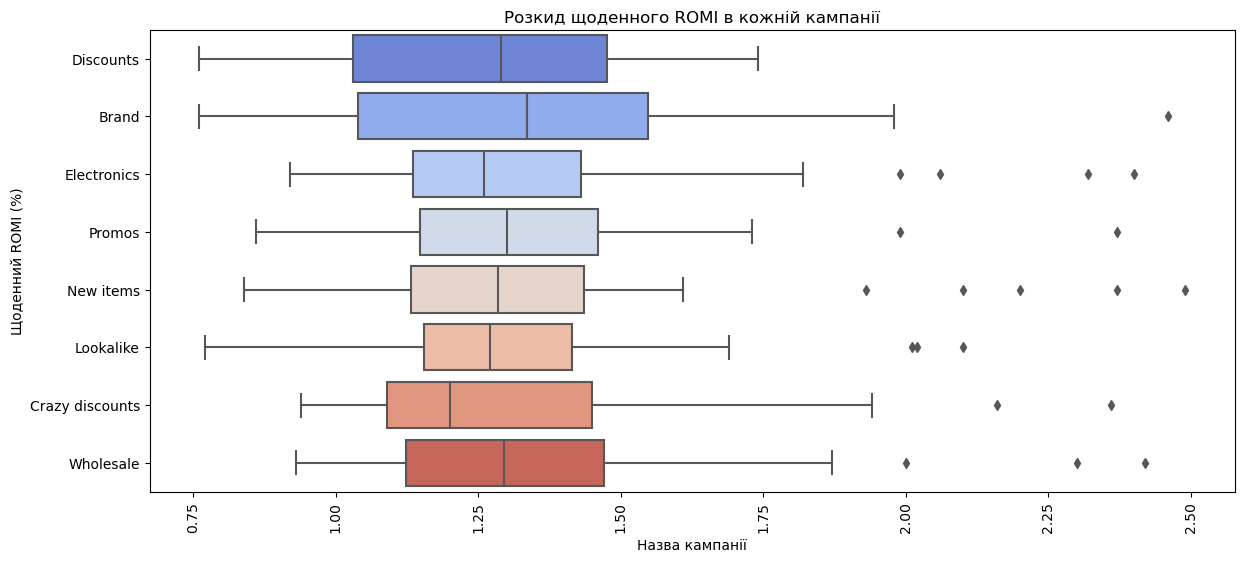

In [40]:
plt.figure(figsize=(14, 6))
sns.boxplot(data=df_4, x='romi', y='campaign_name', palette="coolwarm")
plt.xticks(rotation=90)
plt.title("Розкид щоденного ROMI в кожній кампанії")
plt.xlabel("Назва кампанії")
plt.ylabel("Щоденний ROMI (%)")
plt.show()

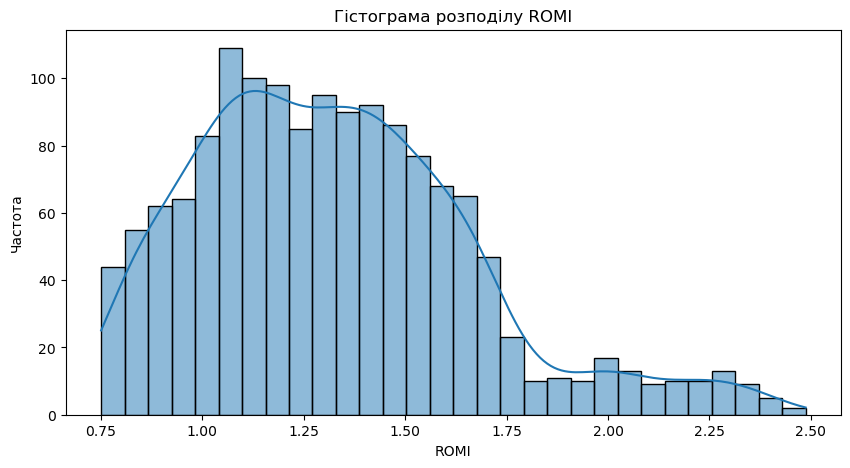

In [41]:
df_facebook
plt.figure(figsize=(10, 5))
sns.histplot(df_facebook['romi'], bins=30, kde=True)
plt.title("Гістограма розподілу ROMI")
plt.xlabel("ROMI")
plt.ylabel("Частота")
plt.show()


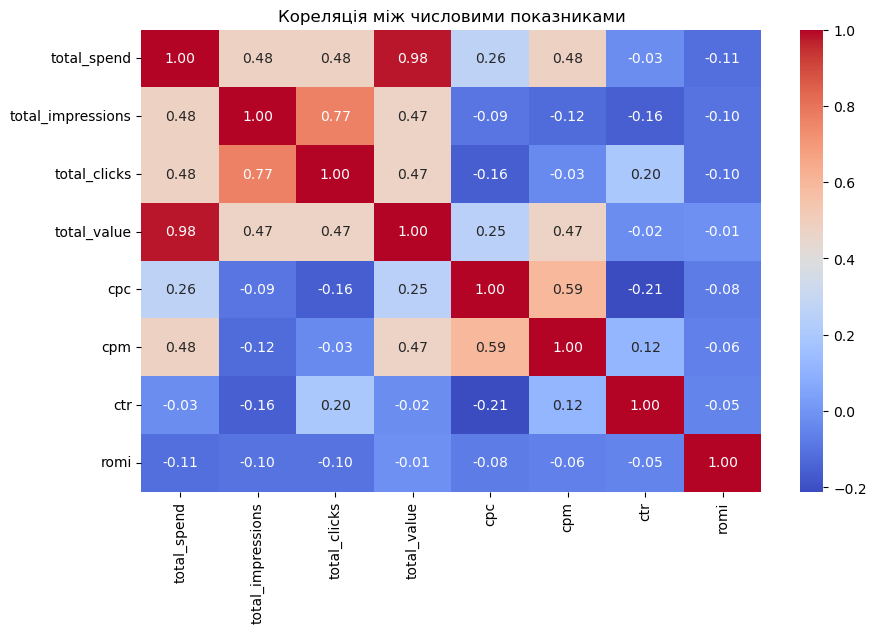

In [42]:
plt.figure(figsize=(10, 6))
sns.heatmap(df_facebook.corr(numeric_only=True), annot=True, cmap="coolwarm", fmt=".2f")
plt.title("Кореляція між числовими показниками")
plt.show()

Найвища кореляція : total_spend та total_value, total_clicks
Найнижча кореляція: ctr', 'romi
total_valueнайбільше корелює з витратами та кліками.

/opt/conda/envs/anaconda-panel-2023.05-py310/lib/python3.11/site-packages/seaborn/axisgrid.py:118: UserWarning: The figure layout has changed to tight
  self._figure.tight_layout(*args, **kwargs)


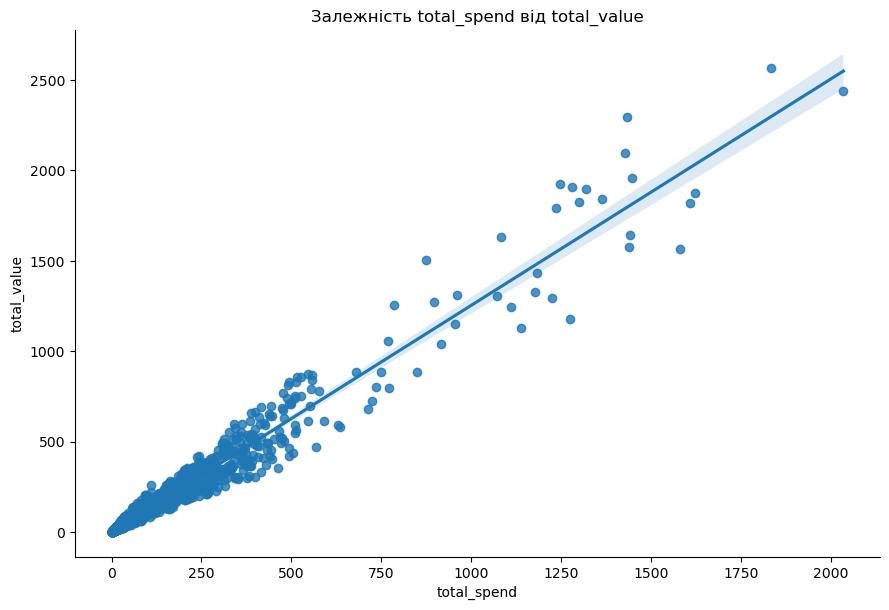

In [43]:
sns.lmplot(data=df_facebook, x='total_spend', y='total_value', height=6, aspect=1.5)
plt.title("Залежність total_spend від total_value")
plt.show()